## Bar Chart


In [1]:
# imports
import polars as pl
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os
import vegafusion as vf

In [2]:
# getting variables to query database
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [3]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""


In [4]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )

In [8]:
df_frequency = (
    df_purchase
    .group_by("user_id")
    .agg(
        pl.col("user_session").n_unique().alias("purchase_frequency")
    )
)


In [14]:
df_frequency.head(100)

user_id,purchase_frequency
i64,u32
583629174,1
568560478,2
559447939,1
562928628,1
606687299,1
…,…
594537892,1
437348045,1
572550292,1


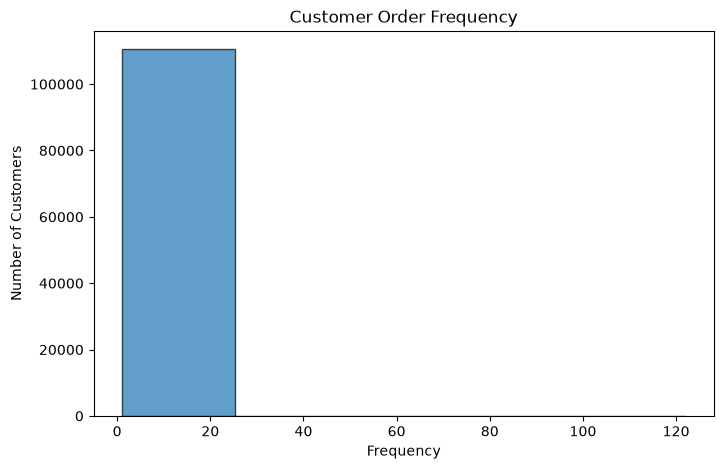

In [10]:
# plot
plt.figure(figsize=(8, 5))

plt.hist(
    df_frequency["purchase_frequency"].to_list(),
    bins=5,
    edgecolor="black",
    alpha=0.7,
)

plt.title("Customer Order Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

## Dollars spent by customers

In [15]:
# create the dataframe for the monetary value
df_monetary = (
    df_purchase
    .group_by("user_id")
    .agg(
        pl.col("price").sum().alias("total_spent")
    )
)


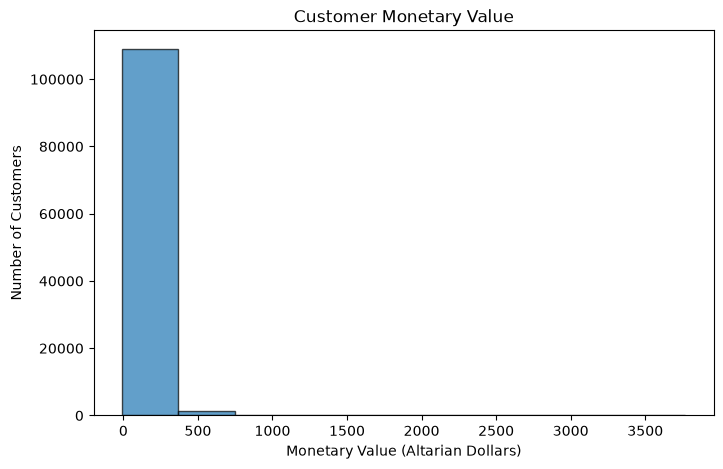

In [16]:
# plotting
plt.figure(figsize=(8, 5))

plt.hist(df_monetary["total_spent"].to_list(), bins=10, edgecolor="black", alpha=0.7)

plt.title("Customer Monetary Value")
plt.xlabel("Monetary Value (Altarian Dollars)")
plt.ylabel("Number of Customers")
plt.show()